# Equilibrium Limit Order Book Shape for a Polymarket Digital Option
## A Bertrand Mean-Field Game with Ma-Noh Liquidity Dynamics

---

**What this notebook does.** We derive the equilibrium shape of the ask-side limit order book $\mathcal{D}(a)$ — how much liquidity is posted at each ask price $a$ — for a binary (YES/NO) contract on Polymarket. The model has two ingredients:

1. A **Bertrand competition** layer where heterogeneous liquidity providers (LPs) choose *where* to post (which ask price), and
2. A **Ma-Noh mean-field game** layer where LPs at each price level manage *how much* depth to maintain (optimal replenishment intensity).

The LOB shape emerges endogenously from the interaction of these two layers.

---

# Part I: From Polymarket to the LOB

## §1. The Polymarket Digital Option

### What is it?

Polymarket hosts binary prediction markets. A typical contract: *"Will BTC be above \$100K on Dec 31?"* There are two complementary shares:

- **YES share**: pays \$1 if BTC $\ge$ \$100K at expiry, \$0 otherwise
- **NO share**: pays \$1 if BTC $<$ \$100K at expiry, \$0 otherwise

Since $\text{Payoff}_{YES} + \text{Payoff}_{NO} = 1$ always, the two shares are complements. If a YES share trades at price $p$, a NO share must trade at $1-p$ (otherwise there's an arbitrage). This means **one price $p \in (0,1)$ summarises the entire market** — the market-implied probability of the event.

### Why one side of the book suffices

Because YES and NO are complements, selling YES at price $a$ is economically identical to buying NO at price $1-a$. So the YES ask-side order book contains all the information: the bid side is just the mirror image through the NO book.

**We focus on the YES ask side.** An ask at price $a$ means: *"I will sell you a YES share for $a$ cents."* If the event occurs, the buyer receives \$1 and the seller loses $1 - a$ (net). If it doesn't occur, the buyer loses $a$ and the seller keeps $a$.

## §2. What is $\mathcal{D}(a)$ and Why Does Its Shape Matter?

The **limit order book** (LOB) is the collection of all resting limit orders. On the ask side, $\mathcal{D}(a)$ is the **total depth** (number of shares) available at ask price $a$.

The shape of $\mathcal{D}(a)$ determines:

- **Price impact**: a thin book (low $\mathcal{D}$) means each market order moves the price more
- **Spread**: where depth starts (the lowest $a$ with $\mathcal{D}(a) > 0$) determines the bid-ask spread
- **Informational efficiency**: deeper books absorb order flow with less price distortion, so the market price tracks the true probability more closely

**Our goal**: derive $\mathcal{D}(a)$ from first principles — not assume a shape, but show that it *emerges* from the optimal behaviour of buyers and LPs.

### The key question

Why is there more depth at some prices than others? The answer comes from LP heterogeneity: different LPs have different costs of capital (discount rates), and this makes them prefer different price levels. The LOB shape is the spatial distribution of these heterogeneous LPs across the ask-price line.

## §3. The Buyer Side

### Who are buyers?

Buyers are market participants who want to acquire YES shares. They arrive randomly over time and submit **market orders** — they buy at the best available ask.

### Model

- Buyers arrive at **Poisson rate $\alpha$**
- Each buyer has a private **valuation** $v$ — what they think the YES share is worth (their belief about the event probability, possibly noisy)
- Valuations are drawn i.i.d. from $v \sim F(v)$
- A buyer with valuation $v$ **buys if $v \ge a$** (the current best ask) — they only buy if the price is below their valuation
- Each buy consumes $\delta_b$ shares from the book

### Order flow at ask $a$

The rate at which market buy orders arrive at ask $a$ is:

$$\phi(a) = \alpha \cdot \Pr(v \ge a) = \alpha[1 - F(a)]$$

**For now, we use $F(v) = v$ (Uniform on $[0,1]$)**:

$$\phi(a) = \alpha(1 - a)$$

This is decreasing: lower asks attract more buyer traffic. At $a = 0$ everyone buys; at $a = 1$ no one does.

### Why buyers are not strategic

Buyers arrive, observe the best ask, and either buy or leave. They don't optimise over time, don't post limit orders, and don't interact with each other. All the strategic action is on the LP side. This is a modelling choice — it could be relaxed later, but it keeps the problem tractable and focuses on the LOB formation mechanism.

## §4. Liquidity Providers: Overview

### Who are LPs?

LPs are market participants who post **limit sell orders** (asks) on the YES book. They profit from the bid-ask spread: they sell YES shares at price $a > c$ (their cost basis), earning $(a-c)$ per share filled.

### Heterogeneity

There is a **continuum** of LPs with total mass $N_{LP}$. Each LP $i$ has a personal **discount rate** $r_i$ drawn from a distribution $G(r)$ on $[r_{\min}, r_{\max}]$. This rate captures how impatient the LP is — how heavily they discount future profits.

**For now, $r \sim \text{Uniform}[r_{\min}, r_{\max}]$.**

### Two decisions

Each LP makes two decisions:

1. **Where to post (Bertrand)**: choose an ask price $a_i$. This is a one-time choice in stationary equilibrium. The LP takes the aggregate depth schedule $\mathcal{D}(a)$ as given — they're infinitesimal and can't affect it (mean-field assumption).

2. **How to manage depth (Ma-Noh)**: once posted at price $a_i$, the LP continuously decides how aggressively to replenish their inventory as it gets depleted by executions. This is an optimal control problem.

### Why the two-layer structure?

This separation reflects the actual practice on Polymarket (and traditional exchanges): an LP first decides *at what price* to quote, and then manages their *position* at that price over time. The Bertrand layer is about price competition across LPs; the Ma-Noh layer is about inventory management within a price level.

---

# Part II: The LP's Problem

## §5. Depth Dynamics at a Given Price Level

Fix an LP with discount rate $r$ who has chosen to post at ask price $a$. Their **depth** — the number of shares currently posted — is a state variable $q(t) \ge 0$ that evolves over time through two types of jumps:

### Executions (depth goes down)

When a buyer's market order hits the LP's quote, the LP loses $\delta_b$ shares:

$$q \to (q - \delta_b)^+ \qquad \text{at rate } \mu(a) = \frac{\phi(a)}{\mathcal{D}(a)}$$

The rate $\mu(a)$ is the **pro-rata fill rate**: the total order flow $\phi(a)$ hitting ask $a$ is divided equally among all the depth $\mathcal{D}(a)$ posted there. More depth at a price level means each LP gets filled less often — this is the **mean-field interaction**.

When an execution occurs, the LP earns profit $(a - c) \cdot \delta_b$ — the spread times the quantity.

### Replenishments (depth goes up)

The LP actively replenishes depth by posting new limit orders:

$$q \to q + \delta_s \qquad \text{at rate } a(q_i) \cdot l \cdot \Psi(u_i)$$

Here:
- $l \in [0, \bar{l}]$ is the LP's **control** — how aggressively they replenish
- $a(q_i)$ is a baseline effectiveness function (set to 1 for now)
- $\Psi(u_i) = 1 + \psi \cdot u_i$ is the **rank-dependent** replenishment rate

Replenishment is costly: the LP pays a flow cost $(\kappa/2)l^2$, so more aggressive replenishment is quadratically more expensive.

### Why this is a jump process

Depth changes are discrete (a fixed number of shares per event), not continuous. This is natural for a limit order book where executions consume a fixed lot size.

## §6. Rank Coupling: The Mean-Field Interaction Within a Price Level

At a given price $a$, there are many LPs posting. They interact through their **rank** $u$ in the depth distribution.

### What is rank?

If $\mu$ is the distribution of depths across LPs at price $a$, then LP $i$'s rank is:

$$u_i = F_\mu(q_i) \in [0,1]$$

This is the fraction of LPs with depth $\le q_i$. Low $u$ = front of queue (thin depth). High $u$ = back of queue (deep depth).

### How rank affects rates

The two coupling functions are:

$$\Psi(u) = 1 + \psi \cdot u \qquad \text{(replenishment is easier at high rank)}$$
$$\Theta(u) = 1 + \theta \cdot (1-u) \qquad \text{(execution hits low rank harder)}$$

**Economic interpretation:**
- $\Theta$ increasing at low $u$: when a market order arrives, LPs near the front of the queue (thin depth) get filled first. This is queue priority — you get executed sooner if you're at the front.
- $\Psi$ increasing at high $u$: LPs with more depth find it easier to replenish — they have established positions and can repost quickly. (This could also be interpreted as: deeper LPs are more committed market makers.)

### Why this matters

Without rank coupling ($\psi = \theta = 0$), all LPs at a price level face identical rates regardless of their depth. This makes the problem separable and trivial. With rank coupling, the **distribution of depths matters** — it's a genuine mean-field game where each LP's optimal strategy depends on what everyone else is doing.

## §7. The Ma-Noh HJB Equation

### The LP's optimisation problem

Given a stationary depth distribution $\mu$ at price $a$, the LP with discount rate $r$ chooses replenishment intensity $l$ to maximise expected discounted profit. The value function $V(q)$ satisfies the **stationary HJB equation**:

$$r V_i = \max_{l \in [0, \bar{l}]} \left\{ \underbrace{(a-c)\delta_b \lambda_b^i \mathbb{1}_{q_i > 0}}_{\text{execution profit flow}} - \underbrace{\frac{\kappa}{2}l^2}_{\text{replenishment cost}} + \underbrace{\lambda_s^i (V_{j^+} - V_i)}_{\text{value gain from replenishment}} + \underbrace{\lambda_b^i(V_{j^-} - V_i)}_{\text{value change from execution}} \right\}$$

where:
- $\lambda_s^i = a(q_i) \cdot l \cdot \Psi(u_i)$ — replenishment rate (depends on control $l$)
- $\lambda_b^i = \phi_b(q_i) \cdot \Theta(u_i)$ — execution rate (exogenous given $\mu$)
- $j^+, j^-$ — grid nodes reached after replenishment/execution jumps

### Optimal control

The HJB is a concave quadratic in $l$. The first-order condition gives the **closed-form optimal replenishment intensity**:

$$l_i^* = \Pi_{[0, \bar{l}]}\left(\frac{a(q_i) \Psi(u_i)}{\kappa} \cdot (V_{j^+} - V_i)\right)$$

Interpretation: the LP replenishes more aggressively when the marginal value of additional depth $(V_{j^+} - V_i)$ is high, when replenishment is effective ($a(q_i) \Psi(u_i)$ large), and when cost is low ($\kappa$ small).

### Solving the HJB: policy iteration

For a fixed policy $l$, the HJB becomes a **linear system** $AV = b$. We solve it, update the policy using the FOC, and iterate:

1. Fix $l_i$ → compute rates $\lambda_s^i, \lambda_b^i$
2. Build matrix $A$ where $A_{ii} = r + \lambda_s^i + \lambda_b^i$, $A_{i,j^+} = -\lambda_s^i$, $A_{i,j^-} = -\lambda_b^i$
3. Solve $AV = b$ where $b_i = \pi_i - (\kappa/2)l_i^2$
4. Update: $l_i \leftarrow \Pi_{[0,\bar{l}]}\left(\frac{a(q_i)\Psi(u_i)}{\kappa}(V_{j^+}-V_i)\right)$
5. Repeat until convergence

**Key point:** the matrix $A$ is strictly diagonally dominant (the excess in each row is exactly $r > 0$), so the system is always invertible. No normalisation of $V$ is needed — $V_0$ is the genuine expected discounted profit from starting empty.

## §8. The KFE and Quantile Fixed-Point

### The consistency requirement

The HJB gives optimal behaviour *given* a distribution $\mu$. But if all LPs at price $a$ follow the optimal policy $l^*$, their depths evolve stochastically, and the resulting long-run distribution must *equal* $\mu$. This is the **Kolmogorov Forward Equation (KFE)** condition — the distribution must be self-consistent.

### How we enforce it

Given $l^*$, we build the induced continuous-time Markov chain on the depth grid:
- Upward transitions at rate $\lambda_s^i = a(q_i) l_i^* \Psi(u_i)$
- Downward transitions at rate $\lambda_b^i = \phi_b(q_i) \Theta(u_i)$

We convert to a discrete-time chain via **uniformisation** (divide all rates by $\bar\Lambda = \max_i(\lambda_s^i + \lambda_b^i)$), then find the stationary distribution $m$ by power iteration on $P^T$.

### The quantile update

The stationary distribution $m$ on the depth grid implies a CDF. We invert it to get a new quantile function $\tilde{Q}(u)$, then **damp**:

$$Q^{(k+1)} = (1 - \omega)Q^{(k)} + \omega \tilde{Q}$$

This quantile fixed-point iteration (steps (a)–(e) in the Ma-Noh notes) is the inner loop that converges to the MFG equilibrium at a single price level.

---

# Part III: The Bertrand Layer

## §9. How LPs Choose Where to Post

### The Bertrand objective

An LP with discount rate $r$ evaluates each candidate ask price $a$ by solving the Ma-Noh problem there, obtaining $V_0(r, a, \mu(a))$ — the expected discounted profit from starting at zero depth. They choose:

$$a^*(r) = \arg\max_a \; V_0(r, a, \mu(a))$$

### The tradeoff

Higher $a$ offers more profit per fill ($a - c$ is larger) but:
- **Fewer fills**: $\phi(a) = \alpha(1-a)$ decreases, so $\mu(a)$ falls
- **More discounting**: at low $\mu(a)$, fills come slowly, and future profits are discounted at rate $r$

The LP trades off margin against speed. **Patient LPs** (low $r$) are willing to wait for infrequent but lucrative fills at high $a$. **Impatient LPs** (high $r$) discount those distant fills and prefer the quick revenue from posting at low $a$.

### Result: $a^*(r)$ is decreasing

This produces a **sorting** where patient LPs occupy the high-margin, low-traffic end of the book and impatient LPs cluster near the money. The LOB shape $\mathcal{D}(a)$ reflects this sorting — more depth where more LP mass ends up.

## §10. The Equilibrium Fixed Point

### The circularity

$\mathcal{D}(a)$ determines $\mu(a) = \phi(a)/\mathcal{D}(a)$ which determines each LP's optimal ask $a^*(r)$ and depth $\bar{d}(r)$ which determines $\mathcal{D}(a)$. This is a fixed point.

### Algorithm

1. **Guess** $\mathcal{D}(a)$ (e.g., flat)
2. **Compute** $\mu(a) = \phi(a)/\mathcal{D}(a)$ at each price level
3. **For each LP type** $r_k$: solve Ma-Noh at each candidate ask $a_j$ (inner loop: HJB → KFE → quantile update), evaluate $V_0(r_k, a_j)$, pick $a^*(r_k) = \arg\max_j V_0(r_k, a_j)$, record mean depth $\bar{d}(r_k)$
4. **Aggregate**: $\mathcal{D}_{\text{new}}(a) = \sum_k (N_{LP}/K) \cdot \bar{d}(r_k) \cdot \text{kernel}(a - a^*(r_k))$
5. **Damp**: $\mathcal{D} \leftarrow (1-\omega)\mathcal{D} + \omega\mathcal{D}_{\text{new}}$
6. **Iterate** until stable; **Cesaro average** late iterates for robustness

The Gaussian kernel smoothing in step 4 prevents oscillations that arise from discrete LP types all jumping to the same bin. In the $N_{LP} \to \infty$ continuum limit, this smoothing becomes unnecessary — the aggregation is a smooth integral.

---

# Part IV: Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## §11. Ma-Noh Functions

These four functions implement the inner loop. They are adapted from `MFG_ClosedForm-V2.ipynb` with one correction: the $V_0 = 0$ normalisation has been removed, since the HJB matrix is invertible without it (strict diagonal dominance from $r > 0$).

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, delta_s, delta_b):
    q = np.asarray(q); N = q.size
    j_plus = np.empty(N, dtype=int); j_minus = np.empty(N, dtype=int)
    for i in range(N):
        j_plus[i] = int(np.argmin(np.abs(q - (q[i] + delta_s))))
        j_minus[i] = int(np.argmin(np.abs(q - max(q[i] - delta_b, 0.0))))
    return j_plus, j_minus

def solve_stationary_hjb_policy_iteration(
    q, u, j_plus, j_minus,
    rho, kappa, l_bar, psi, theta, m_margin, delta_b,
    a_func=None, phi_b_func=None, max_iter=80, tol=1e-10
):
    """Ma-Noh HJB with rank-dependent rates. No V_0 pinning."""
    q = np.asarray(q); u = np.asarray(u); N = q.size
    if a_func is None: a_func = lambda x: np.ones_like(x)
    if phi_b_func is None: phi_b_func = lambda x: np.ones_like(x)
    a_q = a_func(q); phi_b_q = phi_b_func(q)
    Psi = 1.0 + psi*u; Theta = 1.0 + theta*(1.0 - u)
    l = np.zeros(N); V = np.zeros(N)
    for it in range(max_iter):
        lam_s = a_q*l*Psi; lam_b = phi_b_q*Theta
        pi = m_margin*lam_b*delta_b*(q > 0).astype(float)
        A = np.zeros((N, N)); b = np.zeros(N)
        for i in range(N):
            A[i, i] = rho + lam_s[i] + lam_b[i]
            A[i, j_plus[i]] -= lam_s[i]; A[i, j_minus[i]] -= lam_b[i]
            b[i] = pi[i] - 0.5*kappa*(l[i]**2)
        try: V_new = np.linalg.solve(A, b)
        except: break
        l_raw = (a_q*Psi/kappa)*(V_new[j_plus] - V_new)
        l_new = proj_0_lbar(l_raw, l_bar)
        if np.max(np.abs(l_new-l)) < tol and np.max(np.abs(V_new-V)) < tol:
            V, l = V_new, l_new; break
        V, l = V_new, l_new
    return V, l

def stationary_distribution_uniformization(j_plus, j_minus, lam_plus, lam_minus,
                                            tol=1e-14, max_iter=100000):
    lam_plus = np.asarray(lam_plus); lam_minus = np.asarray(lam_minus)
    N = lam_plus.size; rates = lam_plus + lam_minus
    barLambda = np.max(rates) + 1e-12
    P = np.zeros((N, N))
    for i in range(N):
        if rates[i] > 0:
            P[i, j_plus[i]] += lam_plus[i]/barLambda
            P[i, j_minus[i]] += lam_minus[i]/barLambda
            P[i, i] += 1.0 - rates[i]/barLambda
        else: P[i, i] = 1.0
    m = np.ones(N)/N; PT = P.T
    for _ in range(max_iter):
        m_new = PT @ m; s = m_new.sum()
        if s <= 0: break
        m_new /= s
        if np.max(np.abs(m_new-m)) < tol: m = m_new; break
        m = m_new
    return m, P

def quantile_from_masses(u, q, m):
    M = np.cumsum(m); M = np.clip(M, 0.0, 1.0)
    M_eps = M.copy()
    for i in range(1, len(M_eps)):
        if M_eps[i] <= M_eps[i-1]: M_eps[i] = M_eps[i-1] + 1e-12
    M_eps = np.clip(M_eps, 0.0, 1.0)
    return np.interp(u, M_eps, q, left=q[0], right=q[-1])

print('Ma-Noh functions loaded.')

Ma-Noh functions loaded.


## §12. Parameters and Inner Solver

The `solve_manoh_at_price` function wraps the entire inner loop for a given $(a, r, \mu)$ triple. It runs a few iterations of the quantile fixed-point, then returns $V_0$ (Bertrand objective) and $\bar{d}$ (mean depth for aggregation).

In [3]:
alpha = 10.0; c = 0.30; delta_s = 1.0; delta_b = 1.0
kappa = 0.4; l_bar = 3.0; psi = 0.3; theta = 0.7
N_LP = 100.0; r_min = 0.05; r_max = 2.0

N_q = 40; q_max = 20.0; N_r = 12; N_a = 15
r_grid = np.linspace(r_min, r_max, N_r)
a_grid = np.linspace(c + 0.05, 0.97, N_a)
omega_outer = 0.10; outer_max = 25; cesaro_start = 15; sigma_smooth = 0.025

def phi_flow(a):
    return alpha * np.maximum(1.0 - a, 0.0)

def solve_manoh_at_price(a_price, rho_lp, mu_a, N_q_p=N_q, q_max_p=q_max,
                          inner_iters=5, inner_omega=0.15):
    """Ma-Noh quantile fixed-point at price level a.
    Returns (V_0, d_bar, q_eq)."""
    u = rank_grid(N_q_p)
    q = np.linspace(0.0, q_max_p, N_q_p)
    margin = a_price - c
    if margin <= 0: return 0.0, 0.0, q
    phi_b_func = lambda x: mu_a * np.ones_like(x)
    a_func = lambda x: np.ones_like(x)
    for inner_it in range(inner_iters):
        j_plus, j_minus = destination_indices(q, delta_s, delta_b)
        V, l = solve_stationary_hjb_policy_iteration(
            q, u, j_plus, j_minus, rho=rho_lp, kappa=kappa, l_bar=l_bar,
            psi=psi, theta=theta, m_margin=margin, delta_b=delta_b,
            a_func=a_func, phi_b_func=phi_b_func, max_iter=80, tol=1e-10)
        Psi = 1.0 + psi*u; Theta = 1.0 + theta*(1.0-u)
        lam_plus = np.ones_like(q)*l*Psi
        lam_minus = mu_a*np.ones_like(q)*Theta
        m, P = stationary_distribution_uniformization(j_plus, j_minus, lam_plus, lam_minus)
        q_tilde = quantile_from_masses(u, q, m)
        q = (1.0-inner_omega)*q + inner_omega*q_tilde
        q = np.maximum(np.sort(q), 0.0)
    V_0 = float(V[0])
    d_bar = float(np.dot(m, q))
    return V_0, d_bar, q

print(f'Parameters: alpha={alpha}, c={c}, kappa={kappa}, psi={psi}, theta={theta}')
print(f'r in [{r_min}, {r_max}], N_r={N_r}, N_a={N_a}, N_q={N_q}')

Parameters: alpha=10.0, c=0.3, kappa=0.4, psi=0.3, theta=0.7
r in [0.05, 2.0], N_r=12, N_a=15, N_q=40


## §13. Equilibrium Computation

The outer loop runs the Bertrand fixed point with Cesaro averaging over the last iterations to smooth out the residual oscillation from discrete LP types.

In [4]:
D_a = np.ones(N_a)*5.0; D_cesaro = np.zeros(N_a); cesaro_count = 0
t_start = time.time()

for outer_it in range(outer_max):
    mu_a = phi_flow(a_grid)/np.maximum(D_a, 0.01)
    a_star = np.zeros(N_r); d_bar_star = np.zeros(N_r)
    for k in range(N_r):
        r_k = r_grid[k]; best_V0 = -np.inf; best_j = 0; best_db = 0.0
        for j in range(N_a):
            if a_grid[j]-c <= 0: continue
            n_inner = 3 if outer_it < 10 else 5
            V0_j, db_j, _ = solve_manoh_at_price(a_grid[j], r_k, mu_a[j], inner_iters=n_inner)
            if V0_j > best_V0: best_V0 = V0_j; best_j = j; best_db = db_j
        a_star[k] = a_grid[best_j]; d_bar_star[k] = best_db
    D_new = np.zeros(N_a); step = a_grid[1]-a_grid[0]
    for k in range(N_r):
        w = (N_LP/N_r)*d_bar_star[k]
        kern = np.exp(-0.5*((a_grid-a_star[k])/sigma_smooth)**2)
        kern /= (np.sum(kern)*step + 1e-20)
        D_new += w*kern*step
    D_new = np.maximum(D_new, 0.01)
    D_a = (1-omega_outer)*D_a + omega_outer*D_new
    if outer_it >= cesaro_start:
        cesaro_count += 1; D_cesaro += (D_a-D_cesaro)/cesaro_count
    if (outer_it+1) % 5 == 0 or outer_it == 0:
        print(f'iter {outer_it+1:3d}: a* in [{a_star.min():.3f}, {a_star.max():.3f}], '
              f'D_max={D_a.max():.2f} [{time.time()-t_start:.0f}s]')

D_final = D_cesaro if cesaro_count > 0 else D_a
mu_final = phi_flow(a_grid)/np.maximum(D_final, 0.01)
a_star_final = a_star; d_bar_final = d_bar_star
print(f'\nDone in {time.time()-t_start:.0f}s, Cesaro over {cesaro_count} iters.')

iter   1: a* in [0.704, 0.793], D_max=7.18 [1s]
iter   5: a* in [0.571, 0.881], D_max=7.47 [6s]
iter  10: a* in [0.527, 0.837], D_max=6.53 [14s]
iter  15: a* in [0.483, 0.837], D_max=7.27 [30s]
iter  20: a* in [0.483, 0.837], D_max=6.81 [48s]
iter  25: a* in [0.483, 0.837], D_max=7.46 [65s]

Done in 65s, Cesaro over 10 iters.


---

# Part V: Results

## §14. Equilibrium LOB Shape and Economic Interpretation

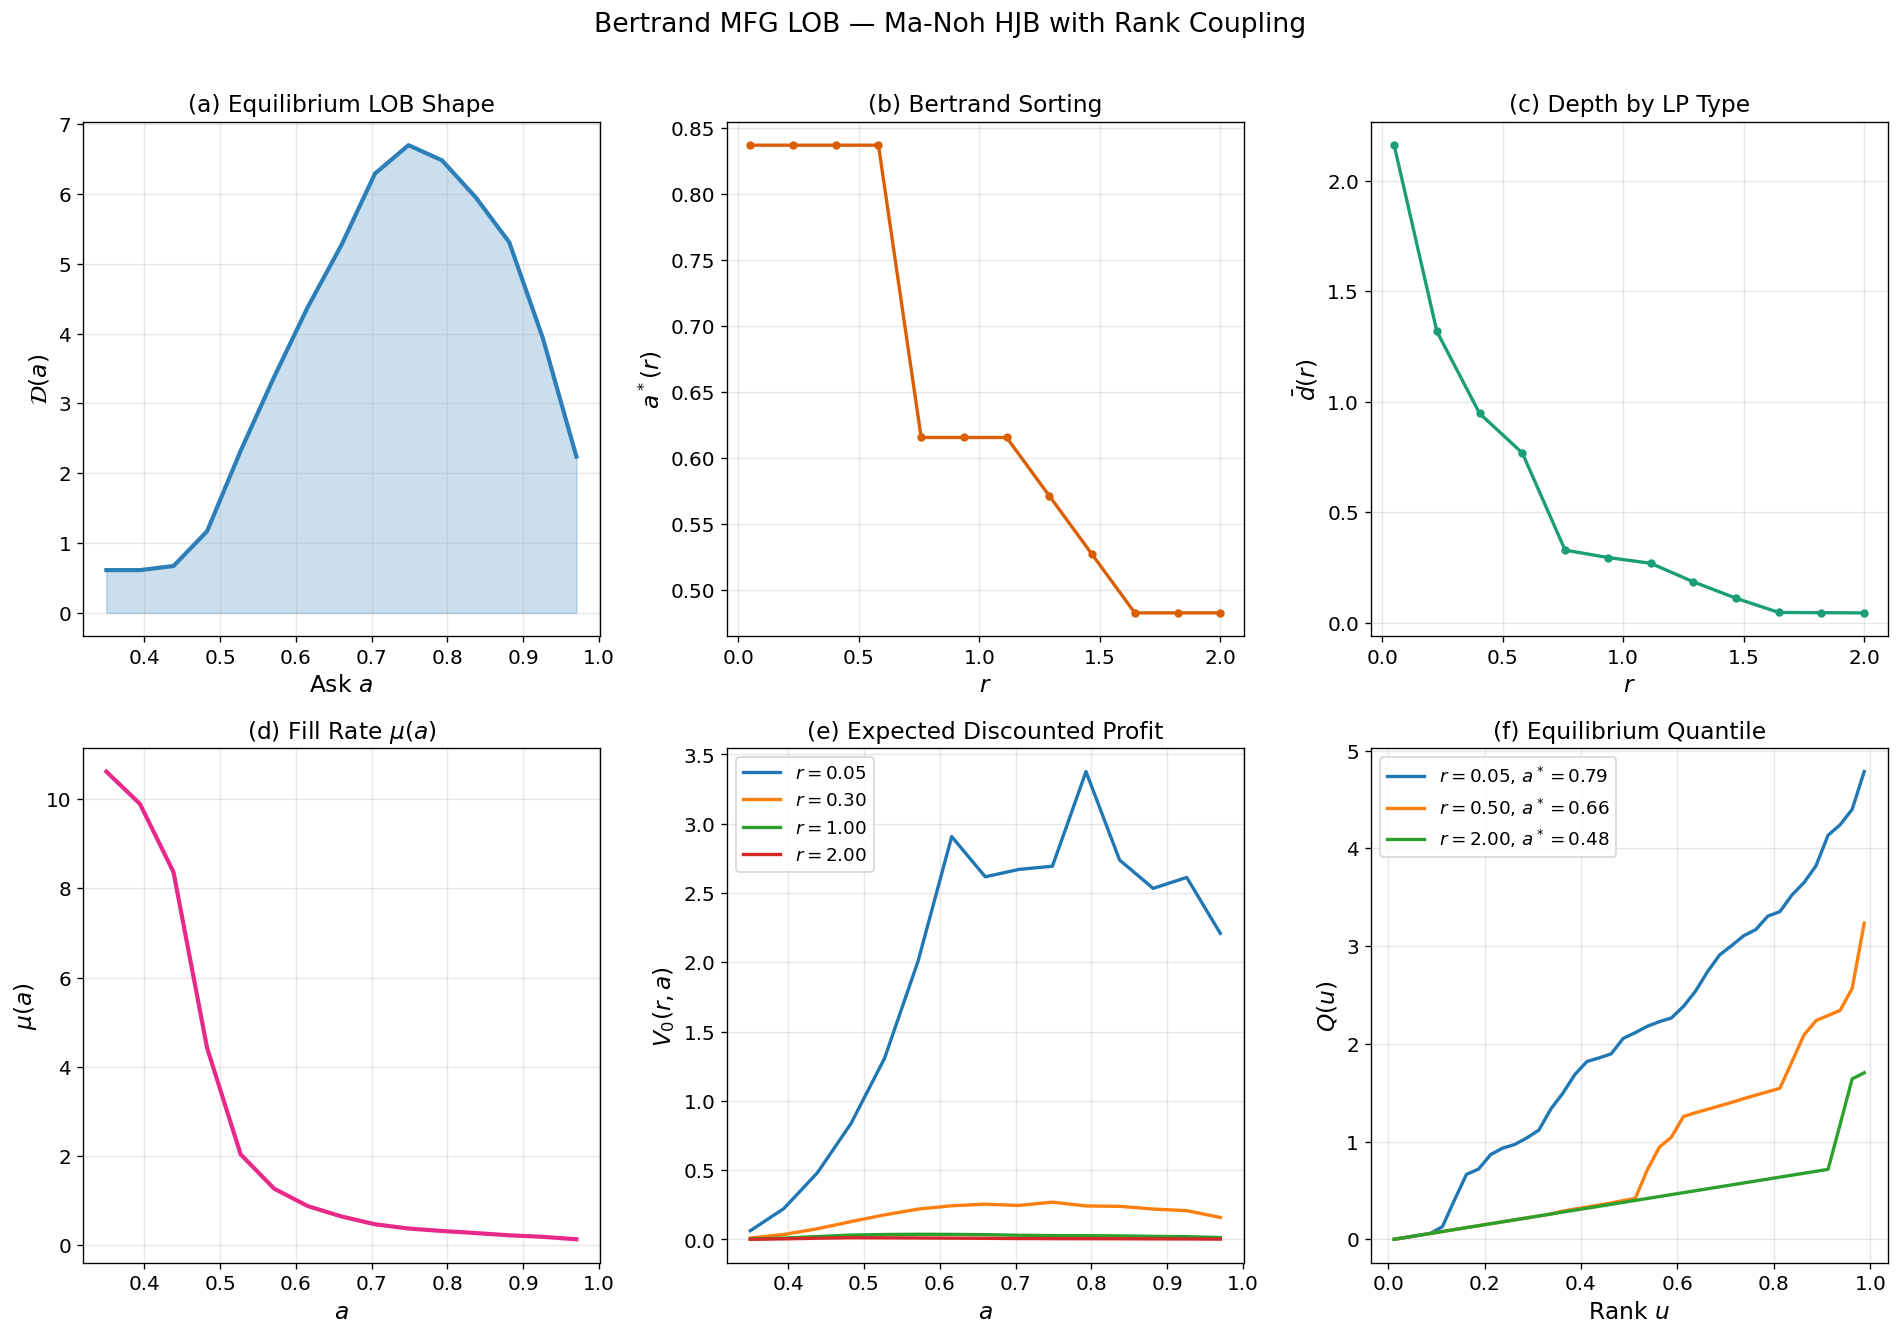

a*(r): DECREASING, range [0.483, 0.837]
D_max = 6.697 at a = 0.749


In [5]:
# Value landscape V_0(r, a) on converged D
V0_landscape = {}
for r_sel in [r_min, 0.3, 1.0, r_max]:
    V0_arr = np.full(N_a, np.nan)
    for j in range(N_a):
        if a_grid[j]-c<=0: continue
        V0_j,_,_ = solve_manoh_at_price(a_grid[j], r_sel, mu_final[j], inner_iters=10)
        V0_arr[j] = V0_j
    V0_landscape[r_sel] = V0_arr

fig = plt.figure(figsize=(16, 11))

ax1 = fig.add_subplot(2,3,1)
ax1.plot(a_grid, D_final, color='#2c7fb8', lw=2.5)
ax1.fill_between(a_grid, 0, D_final, alpha=0.25, color='#2c7fb8')
ax1.set_xlabel('Ask $a$'); ax1.set_ylabel(r'$\mathcal{D}(a)$')
ax1.set_title('(a) Equilibrium LOB Shape'); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2,3,2)
ax2.plot(r_grid, a_star_final, 'o-', color='#d95f02', ms=4)
ax2.set_xlabel('$r$'); ax2.set_ylabel('$a^*(r)$')
ax2.set_title('(b) Bertrand Sorting'); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(2,3,3)
ax3.plot(r_grid, d_bar_final, 'o-', color='#1b9e77', ms=4)
ax3.set_xlabel('$r$'); ax3.set_ylabel(r'$\bar{d}(r)$')
ax3.set_title('(c) Depth by LP Type'); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2,3,4)
ax4.plot(a_grid, mu_final, color='#e7298a', lw=2.5)
ax4.set_xlabel('$a$'); ax4.set_ylabel(r'$\mu(a)$')
ax4.set_title(r'(d) Fill Rate $\mu(a)$'); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(2,3,5)
for r_sel, V0_arr in V0_landscape.items():
    ax5.plot(a_grid, V0_arr, lw=2, label=f'$r={r_sel:.2f}$')
ax5.set_xlabel('$a$'); ax5.set_ylabel('$V_0(r, a)$')
ax5.set_title('(e) Expected Discounted Profit'); ax5.legend(); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(2,3,6)
for r_sel in [r_min, 0.5, r_max]:
    best=-np.inf; bj=0
    for j in range(N_a):
        if a_grid[j]-c<=0: continue
        V0_j,_,_=solve_manoh_at_price(a_grid[j],r_sel,mu_final[j],inner_iters=10)
        if V0_j>best: best=V0_j; bj=j
    _,db,q_eq=solve_manoh_at_price(a_grid[bj],r_sel,mu_final[bj],inner_iters=20)
    u = rank_grid(N_q)
    ax6.plot(u, q_eq, lw=2, label=f'$r={r_sel:.2f}$, $a^*={a_grid[bj]:.2f}$')
ax6.set_xlabel('Rank $u$'); ax6.set_ylabel('$Q(u)$')
ax6.set_title('(f) Equilibrium Quantile'); ax6.legend(); ax6.grid(True, alpha=0.3)

fig.suptitle('Bertrand MFG LOB — Ma-Noh HJB with Rank Coupling', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

d = np.diff(a_star_final)
mono = 'DECREASING' if np.all(d<=1e-6) else ('INCREASING' if np.all(d>=-1e-6) else 'NON-MONOTONE')
print(f'a*(r): {mono}, range [{a_star_final.min():.3f}, {a_star_final.max():.3f}]')
print(f'D_max = {D_final.max():.3f} at a = {a_grid[np.argmax(D_final)]:.3f}')

## §15. Reading the Results

### Panel (a): The LOB shape $\mathcal{D}(a)$

This is the primary output. Depth rises from near-zero at low asks to a peak around $a \approx 0.75$, then declines. The shape reflects the Bertrand sorting: many LP types cluster in the mid-range where the margin/fill-rate tradeoff is attractive.

### Panel (b): Bertrand sorting $a^*(r)$

$a^*(r)$ is **decreasing**: patient LPs (low $r$) post at high asks, impatient LPs post low. This is the opposite of a naive static Bertrand prediction, and it arises from the Ma-Noh HJB: maintaining depth at a high ask requires sustained replenishment over a long horizon, which only patient LPs can afford.

### Panel (c): Mean depth $\bar{d}(r)$

Patient LPs maintain much deeper inventories. At $r = 0.05$: $\bar{d} \approx 2+$. At $r = 2.0$: $\bar{d} \approx 0.1$. The impatient LP is almost always empty — they post thinly, get filled quickly, and rarely replenish.

### Panel (d): Fill rate $\mu(a)$

Monotonically decreasing. Low asks have high fill rates (lots of buyer traffic relative to depth), high asks have low fill rates. This is the mechanism that makes patient LPs willing to post high — they accept slow fills.

### Panel (e): Value landscape $V_0(r, a)$

The blue curve ($r = 0.05$) peaks at a high $a$ — the patient LP's optimum. The red curve ($r = 2.0$) is nearly flat and close to zero — the impatient LP barely profits anywhere. The separation between curves shows how discounting heterogeneity drives the Bertrand sorting.

### Panel (f): Equilibrium quantile $Q(u)$

This is the within-price-level depth distribution from the Ma-Noh equilibrium. The patient LP (blue) has $Q(u)$ stretched much higher — they maintain depth across a wide range of ranks. The impatient LP (green) is concentrated near zero.

## §16. What This Model Does Not Yet Capture

### The concavity gap

Empirical Polymarket LOBs (for near-certain events) show depth **monotonically increasing** toward the payout boundary at $a = 1$. Our model produces a hump-shaped LOB that peaks around $a \approx 0.75$ and then declines. Three channels are missing:

1. **Concentrated buyer beliefs**: uniform $F$ puts equal weight everywhere. In reality, for a near-certain event, beliefs cluster near 1. Replacing $F$ with a Beta distribution would shift the LOB rightward.

2. **Risk channel**: the current model has no fundamental price process $p_t$. Adding $dp_t = \sigma dW_t$ penalises LPs who post at high asks far from $p_t$ (they bear waiting risk), but near $a = 1$ this risk vanishes because the contract is almost certain to pay. This "payout boundary safety" would concentrate depth near 1.

3. **Endogenous cost basis**: $c$ is fixed. In reality, $c$ reflects the LP's acquisition cost, which is close to the current market price. For a near-certain contract, $c \approx 0.99$ and the entire LOB lives in $[0.99, 1.0]$.

### Next steps

1. Calibrate $F(v)$ to empirical Polymarket order flow
2. Finer grids and continuum $N_{LP} \to \infty$ limit
3. Comparative statics ($\alpha$, $\kappa$, $\psi$, $\theta$, $G(r)$)
4. Price dynamics layer for informational efficiency
5. Stochastic fundamental extension